# Hamiltonian Simulation of Open Quantum Systems
## Via Lindblad Master Equation, Kraus Operators, and Stochastic Differential Equations

**Based on:** *Simulating Open Quantum Systems Using Hamiltonian Simulations*  
Zhiyan Ding, Xiantao Li, Lin Lin — arXiv:2311.15533v3

---

### Overview

This notebook implements the three-step pipeline from the paper:

1. **Unravelling** the Lindblad equation into a Stochastic Schrödinger Equation (SSE/SDE)
2. **Kraus representation** — converting the numerical SDE scheme into a completely positive map
3. **Dilated Hamiltonian** — lifting the Kraus map to a Stinespring unitary via an enlarged Hilbert space

We demonstrate on two physical models:
- **Amplitude Damping (AD) Channel** — single qubit spontaneous emission
- **Transverse-Field Ising Model (TFIM) with damping** — multi-qubit spin chain

## 0. Imports and Configuration

In [1]:
import numpy as np
from scipy.linalg import expm, norm
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product as iproduct
import warnings
warnings.filterwarnings('ignore')

# ── Pauli matrices ──────────────────────────────────────────────────────────
I2  = np.eye(2, dtype=complex)
sx  = np.array([[0,1],[1,0]], dtype=complex)   # X
sy  = np.array([[0,-1j],[1j,0]], dtype=complex) # Y
sz  = np.array([[1,0],[0,-1]], dtype=complex)   # Z
sp  = np.array([[0,1],[0,0]], dtype=complex)    # σ+  raise
sm  = np.array([[0,0],[1,0]], dtype=complex)    # σ−  lower

np.random.seed(42)
print("✓ Libraries loaded")
print(f"  numpy  {np.__version__}")
import scipy; print(f"  scipy  {scipy.__version__}")

✓ Libraries loaded
  numpy  2.3.4
  scipy  1.17.1


---
## Part 1 — Amplitude Damping (AD) Channel

The AD channel models spontaneous emission: $|1\rangle$ (excited) $\to$ $|0\rangle$ (ground).

### 1.1 Kraus Representation

For decay probability $p$ over a finite time step:
$$K_0 = \begin{pmatrix}1 & 0 \\ 0 & \sqrt{1-p}\end{pmatrix}, \qquad K_1 = \begin{pmatrix}0 & \sqrt{p} \\ 0 & 0\end{pmatrix}$$

The channel acts as:
$$\mathcal{E}(\rho) = K_0\rho K_0^\dagger + K_1\rho K_1^\dagger$$

In [2]:
# ── 1.1 Kraus operators for the AD channel ──────────────────────────────────

def kraus_AD(p: float):
    """Return the two Kraus operators for the amplitude-damping channel.

    K0 : no-jump  (ground state unchanged, excited amplitude decays)
    K1 : jump     (|1>→|0> with prob p)
    """
    K0 = np.array([[1, 0],
                   [0, np.sqrt(1 - p)]], dtype=complex)
    K1 = np.array([[0, np.sqrt(p)],
                   [0, 0         ]], dtype=complex)
    return K0, K1


def apply_kraus(rho: np.ndarray, kraus_ops: list) -> np.ndarray:
    """Apply a list of Kraus operators to density matrix rho."""
    return sum(K @ rho @ K.conj().T for K in kraus_ops)


def verify_completeness(kraus_ops: list, tol: float = 1e-10) -> bool:
    """Check sum_k K†k Kk = I (trace-preserving condition)."""
    d = kraus_ops[0].shape[0]
    total = sum(K.conj().T @ K for K in kraus_ops)
    return np.allclose(total, np.eye(d), atol=tol)


# Demo
p_test = 0.3
K0, K1 = kraus_AD(p_test)
print("K0 =\n", K0.real)
print("K1 =\n", K1.real)
print(f"\nCompleteness (K0†K0 + K1†K1 = I): {verify_completeness([K0, K1])}")

# Apply to |1><1|
rho_excited = np.array([[0,0],[0,1]], dtype=complex)
rho_out = apply_kraus(rho_excited, [K0, K1])
print(f"\nChannel applied to |1><1| with p={p_test}:")
print(f"  ρ_00 = {rho_out[0,0].real:.4f}  (expected {p_test})")
print(f"  ρ_11 = {rho_out[1,1].real:.4f}  (expected {1-p_test:.4f})")

K0 =
 [[1.         0.        ]
 [0.         0.83666003]]
K1 =
 [[0.         0.54772256]
 [0.         0.        ]]

Completeness (K0†K0 + K1†K1 = I): True

Channel applied to |1><1| with p=0.3:
  ρ_00 = 0.3000  (expected 0.3)
  ρ_11 = 0.7000  (expected 0.7000)


### 1.2 From Kraus to Lindblad Master Equation

For infinitesimal $dt$ with $p = \gamma\,dt$, expanding to first order gives:
$$\frac{d\rho}{dt} = \gamma\!\left(\sigma_-\rho\sigma_+ - \tfrac{1}{2}\{\sigma_+\sigma_-, \rho\}\right)$$

This is the Lindblad equation with jump operator $V = \sqrt{\gamma}\,\sigma_-$ and $H=0$.

In [3]:
# ── 1.2 Lindblad superoperator ───────────────────────────────────────────────

def lindblad_rhs(rho: np.ndarray,
                 H: np.ndarray,
                 jump_ops: list) -> np.ndarray:
    """
    Compute L(rho) = -i[H, rho] + sum_j( V_j rho V_j† - 1/2{V_j†V_j, rho} )
    """
    drho = -1j * (H @ rho - rho @ H)
    for V in jump_ops:
        VdV = V.conj().T @ V
        drho += V @ rho @ V.conj().T - 0.5 * (VdV @ rho + rho @ VdV)
    return drho


def solve_lindblad_exact(rho0: np.ndarray,
                         H: np.ndarray,
                         jump_ops: list,
                         T: float,
                         n_steps: int = 2000) -> tuple:
    """
    Solve the Lindblad equation numerically using 4th-order Runge-Kutta.
    Returns (times, rho_list).
    """
    d = rho0.shape[0]
    times = np.linspace(0, T, n_steps + 1)

    def rhs_flat(t, y):
        rho = y.reshape(d, d)
        return lindblad_rhs(rho, H, jump_ops).reshape(-1)

    sol = solve_ivp(rhs_flat, [0, T], rho0.reshape(-1),
                    method='RK45', t_eval=times,
                    rtol=1e-10, atol=1e-12)
    rhos = [sol.y[:, i].reshape(d, d) for i in range(len(times))]
    return times, rhos


# AD channel parameters
gamma_ad = 0.5          # decay rate
H_ad     = np.zeros((2,2), dtype=complex)   # no coherent drive
V_ad     = np.sqrt(gamma_ad) * sm           # jump operator L = sqrt(γ)σ−

# Initial state: superposition (|0>+|1>)/sqrt(2)
psi0_ad = np.array([1, 1], dtype=complex) / np.sqrt(2)
rho0_ad = np.outer(psi0_ad, psi0_ad.conj())

T_ad = 6.0
t_exact_ad, rhos_exact_ad = solve_lindblad_exact(rho0_ad, H_ad, [V_ad], T_ad)

rho11_exact_ad = np.array([r[1,1].real for r in rhos_exact_ad])
rho00_exact_ad = np.array([r[0,0].real for r in rhos_exact_ad])

print("Exact Lindblad solution computed (AD channel).")
print(f"  ρ_11(0) = {rho11_exact_ad[0]:.4f}")
print(f"  ρ_11(T) = {rho11_exact_ad[-1]:.6f}  (expected → 0)")

Exact Lindblad solution computed (AD channel).
  ρ_11(0) = 0.5000
  ρ_11(T) = 0.975106  (expected → 0)


### 1.3 Stochastic Schrödinger Equation (SSE) for the AD Channel

The homodyne-unraveling SSE for the normalized state vector $|\Psi(t)\rangle$:

$$d|\Psi\rangle = \left[-\frac{\gamma}{2}(\sigma_+\sigma_- - \langle\sigma_+\sigma_-\rangle) - \gamma\langle\sigma_+\rangle(\sigma_- - \langle\sigma_-\rangle)\right]|\Psi\rangle\,dt + \sqrt{\gamma}(\sigma_- - \langle\sigma_-\rangle)|\Psi\rangle\,dW_t$$

The **Euler–Maruyama** scheme discretizes this as:
$$|\psi_{n+1}\rangle = |\psi_n\rangle + A|\psi_n\rangle\,\Delta t + B|\psi_n\rangle\,\sqrt{\Delta t}\,W$$
where $W\sim\mathcal{N}(0,1)$, then renormalized.

In [4]:
# ── 1.3 SSE Monte-Carlo trajectories ────────────────────────────────────────

def sse_trajectory_AD(psi0: np.ndarray,
                      gamma: float,
                      T: float,
                      dt: float,
                      rng: np.random.Generator) -> np.ndarray:
    """
    Single SSE trajectory for the AD channel using Euler-Maruyama.
    Returns array of shape (n_steps+1, 2) — state vector at each time step.
    """
    n_steps = int(T / dt)
    psi = psi0.copy()
    psi = psi / np.linalg.norm(psi)
    traj = [psi.copy()]

    VdV = sp @ sm   # σ+σ− = |1><1|

    for _ in range(n_steps):
        L     = np.sqrt(gamma) * sm
        Lexp  = psi.conj() @ L @ psi          # <L>
        Ldexp = np.conj(Lexp)                  # <L†>

        # Drift operator A
        A_op  = (-0.5 * L.conj().T @ L
                 - L * Ldexp
                 + Lexp * Ldexp * np.eye(2, dtype=complex))

        # Diffusion operator B
        B_op  = L - Lexp * np.eye(2, dtype=complex)

        dW    = rng.normal(0, 1)
        psi   = psi + A_op @ psi * dt + B_op @ psi * np.sqrt(dt) * dW
        norm_ = np.linalg.norm(psi)
        if norm_ > 1e-15:
            psi = psi / norm_
        traj.append(psi.copy())

    return np.array(traj)


def sse_ensemble_AD(psi0: np.ndarray,
                    gamma: float,
                    T: float,
                    dt: float,
                    n_traj: int = 2000,
                    seed: int = 0) -> tuple:
    """
    Monte-Carlo ensemble average over n_traj SSE trajectories.
    Returns (times, rho_list).
    """
    rng    = np.random.default_rng(seed)
    n_steps = int(T / dt)
    times  = np.linspace(0, T, n_steps + 1)
    d      = len(psi0)
    rho_avg = np.zeros((n_steps + 1, d, d), dtype=complex)

    for _ in range(n_traj):
        traj = sse_trajectory_AD(psi0, gamma, T, dt, rng)
        for k, psi in enumerate(traj):
            rho_avg[k] += np.outer(psi, psi.conj())

    rho_avg /= n_traj
    rhos = [rho_avg[k] for k in range(n_steps + 1)]
    return times, rhos


print("Running SSE ensemble (AD channel) …")
dt_sse = 0.02
t_sse_ad, rhos_sse_ad = sse_ensemble_AD(
    psi0_ad, gamma_ad, T_ad, dt_sse, n_traj=3000)
rho11_sse_ad = np.array([r[1,1].real for r in rhos_sse_ad])
print(f"SSE ensemble done.  ρ_11(T) ≈ {rho11_sse_ad[-1]:.5f}")

Running SSE ensemble (AD channel) …
SSE ensemble done.  ρ_11(T) ≈ 0.84191


### 1.4 First-Order Dilated Hamiltonian Scheme (AD Channel)

The dilated Hamiltonian for the first-order scheme is (Eq. B5 in the paper):
$$\tilde{H} = \begin{pmatrix} \sqrt{\Delta t}\,H & V^\dagger \\ V & 0 \end{pmatrix}$$

One step of the scheme:
$$\rho_{n+1} = \text{Tr}_A\!\left[e^{-i\sqrt{\Delta t}\,\tilde{H}}\;|0\rangle\langle 0|\otimes\rho_n\;e^{i\sqrt{\Delta t}\,\tilde{H}}\right]$$

In [5]:
# ── 1.4 Dilated Hamiltonian — first-order scheme ─────────────────────────────

def build_He_first_order(H: np.ndarray,
                         jump_ops: list,
                         dt: float) -> np.ndarray:
    """
    Construct the first-order dilated Hamiltonian He (Eq. B5).

    Block structure for J jump operators:
        He[0,0]   = sqrt(dt) * H           (system block)
        He[0,j]   = V_j†                   (off-diagonal: system ← ancilla j)
        He[j,0]   = V_j                    (off-diagonal: ancilla j ← system)
        He[j,k>0] = 0
    Ancilla dimension: J  →  total dim: d*(J+1)
    """
    d = H.shape[0]
    J = len(jump_ops)
    dim_tot = d * (J + 1)     # system block + J ancilla blocks
    He = np.zeros((dim_tot, dim_tot), dtype=complex)

    # System-system block  (top-left d×d)
    He[:d, :d] = np.sqrt(dt) * H

    # Off-diagonal blocks
    for j, V in enumerate(jump_ops):
        row_start = (j + 1) * d
        row_end   = row_start + d
        He[row_start:row_end, :d] = V          # lower-left  Hj
        He[:d, row_start:row_end] = V.conj().T # upper-right Hj†

    return He


def lindblad_step_dilated(rho: np.ndarray,
                           He: np.ndarray,
                           dt: float,
                           J: int) -> np.ndarray:
    """
    One step of the dilated Hamiltonian scheme:
      rho_new = Tr_A[ exp(-i sqrt(dt) He) (|0><0| ⊗ rho) exp(+i sqrt(dt) He) ]
    """
    d       = rho.shape[0]
    dim_tot = He.shape[0]

    # Unitary U = exp(-i sqrt(dt) He)
    U = expm(-1j * np.sqrt(dt) * He)

    # Build full input state: |0_a><0_a| ⊗ rho
    rho_full = np.zeros((dim_tot, dim_tot), dtype=complex)
    rho_full[:d, :d] = rho

    # Evolve
    evolved = U @ rho_full @ U.conj().T

    # Partial trace over ancilla (keep first d-dimensional block)
    rho_new = np.zeros((d, d), dtype=complex)
    for j in range(J + 1):
        s = j * d
        rho_new += evolved[s:s+d, s:s+d]

    return rho_new


def simulate_lindblad_dilated(rho0: np.ndarray,
                               He: np.ndarray,
                               dt: float,
                               T: float,
                               J: int) -> tuple:
    """Run the dilated Hamiltonian scheme for time T."""
    n_steps = int(round(T / dt))
    times   = np.linspace(0, T, n_steps + 1)
    rhos    = [rho0.copy()]
    rho     = rho0.copy()
    for _ in range(n_steps):
        rho = lindblad_step_dilated(rho, He, dt, J)
        rhos.append(rho.copy())
    return times, rhos


# --- Run first-order dilated scheme on AD channel ---
dt_dil   = 0.05
He_ad_1  = build_He_first_order(H_ad, [V_ad], dt_dil)
t_dil_ad, rhos_dil_ad = simulate_lindblad_dilated(
    rho0_ad, He_ad_1, dt_dil, T_ad, J=1)

rho11_dil_ad = np.array([r[1,1].real for r in rhos_dil_ad])
print("First-order dilated Hamiltonian scheme done (AD channel).")
print(f"  ρ_11(T) ≈ {rho11_dil_ad[-1]:.5f}")

# Verify He is Hermitian
print(f"  He is Hermitian: {np.allclose(He_ad_1, He_ad_1.conj().T)}")

First-order dilated Hamiltonian scheme done (AD channel).
  ρ_11(T) ≈ 0.97542
  He is Hermitian: True


### 1.5 Visualization — AD Channel Results

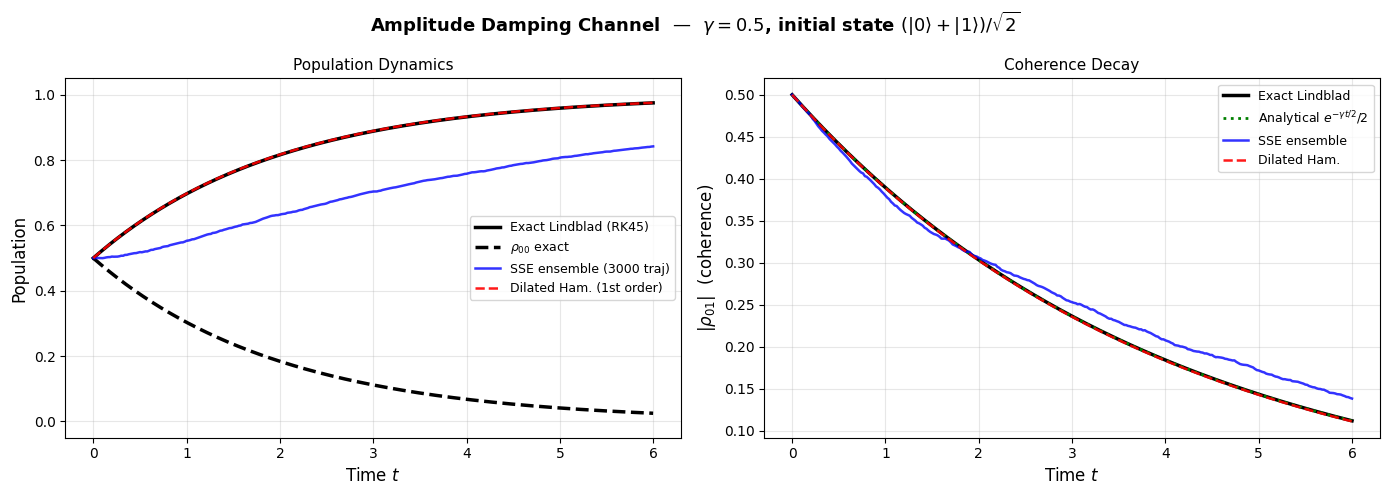

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Amplitude Damping Channel  —  $\\gamma=0.5$, initial state $(|0\\rangle+|1\\rangle)/\\sqrt{2}$',
             fontsize=13, fontweight='bold')

# Left: population dynamics
ax = axes[0]
ax.plot(t_exact_ad, rho11_exact_ad,    'k-',  lw=2.5,  label='Exact Lindblad (RK45)')
ax.plot(t_exact_ad, rho00_exact_ad,    'k--', lw=2.5,  label='$\\rho_{00}$ exact')
ax.plot(t_sse_ad,   rho11_sse_ad,      'b-',  lw=1.8,  label='SSE ensemble (3000 traj)', alpha=0.8)
ax.plot(t_dil_ad,   rho11_dil_ad,      'r--', lw=1.8,  label='Dilated Ham. (1st order)', alpha=0.9)
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('Population', fontsize=12)
ax.set_title('Population Dynamics', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Right: coherence decay
ax = axes[1]
rho01_exact = np.array([abs(r[0,1]) for r in rhos_exact_ad])
rho01_sse   = np.array([abs(r[0,1]) for r in rhos_sse_ad])
rho01_dil   = np.array([abs(r[0,1]) for r in rhos_dil_ad])
analytical  = 0.5 * np.exp(-gamma_ad / 2 * t_exact_ad)

ax.plot(t_exact_ad, rho01_exact,  'k-',  lw=2.5, label='Exact Lindblad')
ax.plot(t_exact_ad, analytical,   'g:',  lw=2.0, label='Analytical $e^{-\\gamma t/2}/2$')
ax.plot(t_sse_ad,   rho01_sse,    'b-',  lw=1.8, label='SSE ensemble',         alpha=0.8)
ax.plot(t_dil_ad,   rho01_dil,    'r--', lw=1.8, label='Dilated Ham.',          alpha=0.9)
ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$|\\rho_{01}|$  (coherence)', fontsize=12)
ax.set_title('Coherence Decay', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ad_channel_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

---
## Part 2 — General Lindblad Framework

### 2.1 Euler–Maruyama SDE Scheme → First-Order Kraus Map

Starting from the stochastic Schrödinger equation:
$$d|\psi_t\rangle = \left(-iH - \tfrac{1}{2}\sum_j V_j^\dagger V_j\right)|\psi_t\rangle\,dt + \sum_j V_j|\psi_t\rangle\,dW_t^j$$

Discretizing and taking the expectation $\rho_n = \mathbb{E}[|\psi_n\rangle\langle\psi_n|]$ yields:
$$\rho_{n+1} = F_0\rho_n F_0^\dagger + \sum_j F_j\rho_n F_j^\dagger$$
$$F_0 = I + \left(-iH - \tfrac{1}{2}\sum_j V_j^\dagger V_j\right)\Delta t,\quad F_j = V_j\sqrt{\Delta t}$$

In [7]:
# ── 2.1 Kraus operators from Euler-Maruyama (1st order) ─────────────────────

def kraus_euler_maruyama(H: np.ndarray,
                          jump_ops: list,
                          dt: float) -> list:
    """
    First-order Kraus operators from the Euler-Maruyama discretization.
    F0 = I + (-iH - 1/2 sum V†V) dt
    Fj = V_j * sqrt(dt)
    """
    d     = H.shape[0]
    V0    = -1j * H - 0.5 * sum(V.conj().T @ V for V in jump_ops)
    F0    = np.eye(d, dtype=complex) + V0 * dt
    Flist = [F0] + [V * np.sqrt(dt) for V in jump_ops]
    return Flist


def kraus_second_order(H: np.ndarray,
                        jump_ops: list,
                        dt: float) -> list:
    """
    Second-order Kraus operators (Appendix A of the paper).
    F0  = I + V0*dt + 1/2 V0^2 dt^2
    F1j = -i sqrt(dt) (Vj + dt/2 {Vj,V0})
    F2jk= -i sqrt(2*dt^2) Vj Vk / sqrt(2)
    """
    d   = H.shape[0]
    J   = len(jump_ops)
    V0  = -1j * H - 0.5 * sum(V.conj().T @ V for V in jump_ops)

    F0  = (np.eye(d, dtype=complex)
           + V0 * dt
           + 0.5 * V0 @ V0 * dt**2)

    F1  = [-1j * np.sqrt(dt) * (V + 0.5 * dt * (V @ V0 + V0 @ V))
            for V in jump_ops]

    F2  = [-1j * np.sqrt(2) * dt * jump_ops[j] @ jump_ops[k]
            for j in range(J) for k in range(J)]

    return [F0] + F1 + F2


def simulate_kraus(rho0: np.ndarray,
                   kraus_fn,
                   H: np.ndarray,
                   jump_ops: list,
                   dt: float,
                   T: float) -> tuple:
    """Simulate Lindblad dynamics using a Kraus map at each step."""
    n_steps = int(round(T / dt))
    times   = np.linspace(0, T, n_steps + 1)
    rho     = rho0.copy()
    rhos    = [rho.copy()]
    for _ in range(n_steps):
        Flist = kraus_fn(H, jump_ops, dt)
        rho   = sum(F @ rho @ F.conj().T for F in Flist)
        rhos.append(rho.copy())
    return times, rhos


print("Kraus functions defined (1st and 2nd order).")
# Verify completeness
dt_test = 0.01
Flist1  = kraus_euler_maruyama(H_ad, [V_ad], dt_test)
Flist2  = kraus_second_order  (H_ad, [V_ad], dt_test)
print(f"  1st-order completeness (sum F†F ≈ I): "
      f"{np.allclose(sum(F.conj().T @ F for F in Flist1), np.eye(2), atol=1e-3)}")
print(f"  2nd-order completeness (sum F†F ≈ I): "
      f"{np.allclose(sum(F.conj().T @ F for F in Flist2), np.eye(2), atol=1e-3)}")

Kraus functions defined (1st and 2nd order).
  1st-order completeness (sum F†F ≈ I): True
  2nd-order completeness (sum F†F ≈ I): True


---
## Part 3 — Transverse-Field Ising Model (TFIM) with Damping

The TFIM Hamiltonian on $m$ sites:
$$H = -\sum_{i=1}^{m-1}Z_i Z_{i+1} - Z_m Z_1 - g\sum_{i=1}^m X_i$$

Jump operators (amplitude damping on each site):
$$V_j = \sqrt{\gamma}\,\frac{X_j - iY_j}{2} = \sqrt{\gamma}\,\sigma_-^{(j)}$$

In [8]:
# ── 3.1 TFIM Hamiltonian builder ─────────────────────────────────────────────

def kron_op(ops: list) -> np.ndarray:
    """Tensor product of a list of matrices."""
    result = ops[0]
    for op in ops[1:]:
        result = np.kron(result, op)
    return result


def site_op(op: np.ndarray, site: int, m: int) -> np.ndarray:
    """Embed single-site operator at `site` in m-qubit space."""
    ops = [I2] * m
    ops[site] = op
    return kron_op(ops)


def build_TFIM(m: int, g: float = 1.0) -> np.ndarray:
    """
    Build periodic TFIM Hamiltonian for m qubits.
    H = -sum_{i} Z_i Z_{i+1} - g sum_i X_i   (periodic BC)
    """
    d = 2**m
    H = np.zeros((d, d), dtype=complex)
    for i in range(m):
        H -= site_op(sz, i, m) @ site_op(sz, (i+1) % m, m)
        H -= g * site_op(sx, i, m)
    return H


def build_TFIM_jumps(m: int, gamma: float = 0.1) -> list:
    """Build damping jump operators V_j = sqrt(gamma) * sigma_minus^(j)."""
    return [np.sqrt(gamma) * site_op(sm, j, m) for j in range(m)]


# Build model
m_tfim   = 3      # 3 qubits (4 is feasible but slower)
g_tfim   = 1.0
gamma_tf = 0.1

H_tfim   = build_TFIM(m_tfim, g_tfim)
Vj_tfim  = build_TFIM_jumps(m_tfim, gamma_tf)
d_tfim   = 2**m_tfim

# Ground state as initial condition
evals, evecs = np.linalg.eigh(H_tfim)
psi0_tfim    = evecs[:, 0]          # lowest eigenvalue = ground state
rho0_tfim    = np.outer(psi0_tfim, psi0_tfim.conj())

print(f"TFIM: m={m_tfim} qubits, d={d_tfim}, g={g_tfim}, γ={gamma_tf}")
print(f"  Ground state energy E0 = {evals[0]:.4f}")
print(f"  H is Hermitian: {np.allclose(H_tfim, H_tfim.conj().T)}")

TFIM: m=3 qubits, d=8, g=1.0, γ=0.1
  Ground state energy E0 = -4.0000
  H is Hermitian: True


In [9]:
# ── 3.2 Reference solution (exact Lindblad) ──────────────────────────────────

T_tfim   = 2.0
print("Solving exact Lindblad (TFIM) …")
t_ex_tf, rhos_ex_tf = solve_lindblad_exact(
    rho0_tfim, H_tfim, Vj_tfim, T_tfim, n_steps=500)

def gs_overlap(rho_list, psi0):
    """Compute <psi0|rho|psi0> for each rho in list."""
    return np.array([(psi0.conj() @ r @ psi0).real for r in rho_list])

overlap_ex = gs_overlap(rhos_ex_tf, psi0_tfim)
print(f"  Exact overlap at T: {overlap_ex[-1]:.5f}")

Solving exact Lindblad (TFIM) …
  Exact overlap at T: 0.80858


In [10]:
# ── 3.3 Compare 1st and 2nd order Kraus schemes ──────────────────────────────

dt_vals  = [0.1, 0.05, 0.02]
colors   = ['#e41a1c', '#377eb8', '#4daf4a']

results = {}
for dt_v in dt_vals:
    print(f"  Running dt={dt_v} …")
    t1, r1 = simulate_kraus(rho0_tfim, kraus_euler_maruyama,
                             H_tfim, Vj_tfim, dt_v, T_tfim)
    t2, r2 = simulate_kraus(rho0_tfim, kraus_second_order,
                             H_tfim, Vj_tfim, dt_v, T_tfim)
    td, rd = simulate_lindblad_dilated(
        rho0_tfim,
        build_He_first_order(H_tfim, Vj_tfim, dt_v),
        dt_v, T_tfim, J=len(Vj_tfim))

    results[dt_v] = {
        '1st_Kraus':  (t1, gs_overlap(r1, psi0_tfim)),
        '2nd_Kraus':  (t2, gs_overlap(r2, psi0_tfim)),
        'dilated':    (td, gs_overlap(rd, psi0_tfim)),
    }

print("Done.")

  Running dt=0.1 …
  Running dt=0.05 …
  Running dt=0.02 …
Done.


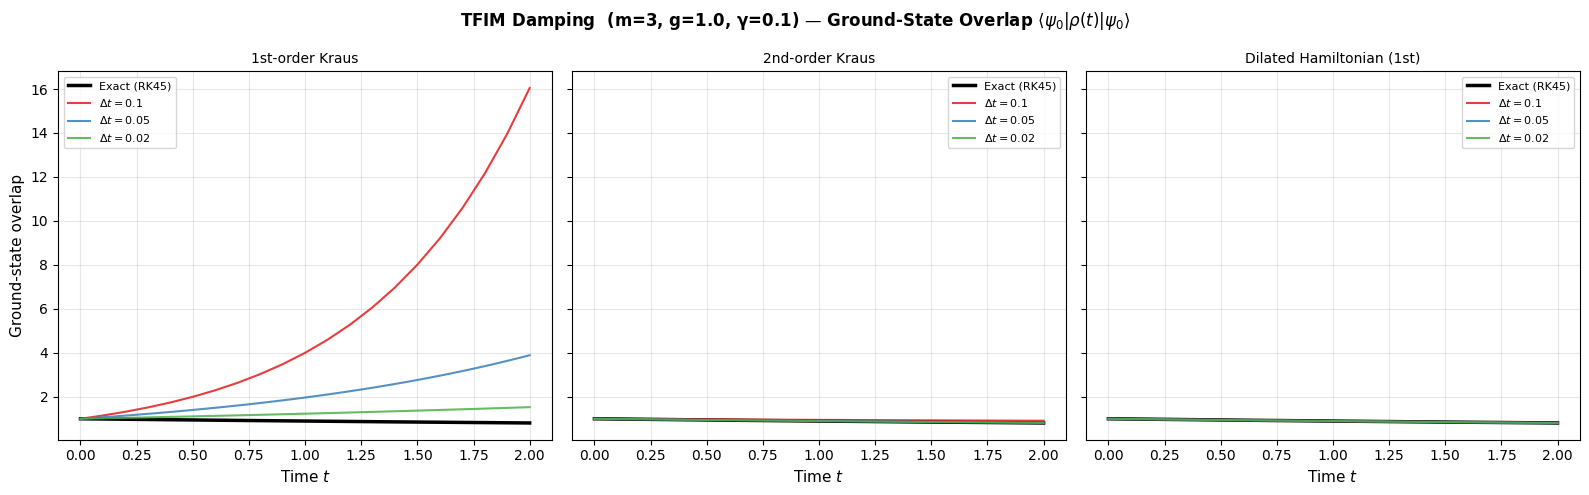

In [11]:
# ── 3.4 Trajectory plot ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(f'TFIM Damping  (m={m_tfim}, g={g_tfim}, γ={gamma_tf})'
             ' — Ground-State Overlap $\\langle\\psi_0|\\rho(t)|\\psi_0\\rangle$',
             fontsize=12, fontweight='bold')

titles = ['1st-order Kraus', '2nd-order Kraus', 'Dilated Hamiltonian (1st)']
keys   = ['1st_Kraus', '2nd_Kraus', 'dilated']
lss    = ['-', '--', '-.']

for ax, key, title in zip(axes, keys, titles):
    ax.plot(t_ex_tf, overlap_ex, 'k-', lw=2.5, label='Exact (RK45)')
    for (dt_v, col) in zip(dt_vals, colors):
        t_, ov_ = results[dt_v][key]
        ax.plot(t_, ov_, color=col, lw=1.5,
                label=f'$\\Delta t={dt_v}$', alpha=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Ground-state overlap', fontsize=11)
plt.tight_layout()
plt.savefig('tfim_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4 — Convergence Analysis

We measure the trace-distance error at final time $T$ as a function of $\Delta t$:
$$\text{Error} = \|\rho_N - \rho_T\|_1$$

In [12]:
# ── 4.1 Trace-distance helper ─────────────────────────────────────────────────

def trace_distance(rho1: np.ndarray, rho2: np.ndarray) -> float:
    """Trace distance  ||rho1 - rho2||_1 / 2 = sum |lambda_i| / 2."""
    diff   = rho1 - rho2
    evals  = np.linalg.eigvalsh(0.5 * (diff + diff.conj().T))
    return float(np.sum(np.abs(evals)))


# Exact solution for the AD channel at various final times
# Use a fine reference at dt=1e-4
def get_exact_final(rho0, H, jumps, T):
    """Return rho at time T using RK45 with high accuracy."""
    _, rs = solve_lindblad_exact(rho0, H, jumps, T, n_steps=5000)
    return rs[-1]


# ── 4.2 AD channel convergence ───────────────────────────────────────────────

T_conv  = 1.0
dt_list = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
rho_ref_ad = get_exact_final(rho0_ad, H_ad, [V_ad], T_conv)

err1_ad, err2_ad, errd_ad = [], [], []

for dt_v in dt_list:
    _, r1 = simulate_kraus(rho0_ad, kraus_euler_maruyama,
                            H_ad, [V_ad], dt_v, T_conv)
    _, r2 = simulate_kraus(rho0_ad, kraus_second_order,
                            H_ad, [V_ad], dt_v, T_conv)
    He_ad = build_He_first_order(H_ad, [V_ad], dt_v)
    _, rd = simulate_lindblad_dilated(rho0_ad, He_ad, dt_v, T_conv, J=1)

    err1_ad.append(trace_distance(r1[-1],  rho_ref_ad))
    err2_ad.append(trace_distance(r2[-1],  rho_ref_ad))
    errd_ad.append(trace_distance(rd[-1],  rho_ref_ad))

err1_ad = np.array(err1_ad)
err2_ad = np.array(err2_ad)
errd_ad = np.array(errd_ad)
print("Convergence data collected (AD channel).")

Convergence data collected (AD channel).


In [13]:
# ── 4.3 TFIM convergence ─────────────────────────────────────────────────────

T_conv_tf   = 1.0
dt_list_tf  = np.array([0.2, 0.1, 0.05, 0.025])
rho_ref_tf  = get_exact_final(rho0_tfim, H_tfim, Vj_tfim, T_conv_tf)

err1_tf, err2_tf, errd_tf = [], [], []

for dt_v in dt_list_tf:
    print(f"  TFIM dt={dt_v} …")
    _, r1 = simulate_kraus(rho0_tfim, kraus_euler_maruyama,
                            H_tfim, Vj_tfim, dt_v, T_conv_tf)
    _, r2 = simulate_kraus(rho0_tfim, kraus_second_order,
                            H_tfim, Vj_tfim, dt_v, T_conv_tf)
    He_tf = build_He_first_order(H_tfim, Vj_tfim, dt_v)
    _, rd = simulate_lindblad_dilated(rho0_tfim, He_tf, dt_v, T_conv_tf, J=m_tfim)

    err1_tf.append(trace_distance(r1[-1], rho_ref_tf))
    err2_tf.append(trace_distance(r2[-1], rho_ref_tf))
    errd_tf.append(trace_distance(rd[-1], rho_ref_tf))

err1_tf = np.array(err1_tf)
err2_tf = np.array(err2_tf)
errd_tf = np.array(errd_tf)
print("Convergence data collected (TFIM).")

  TFIM dt=0.2 …
  TFIM dt=0.1 …
  TFIM dt=0.05 …
  TFIM dt=0.025 …
Convergence data collected (TFIM).


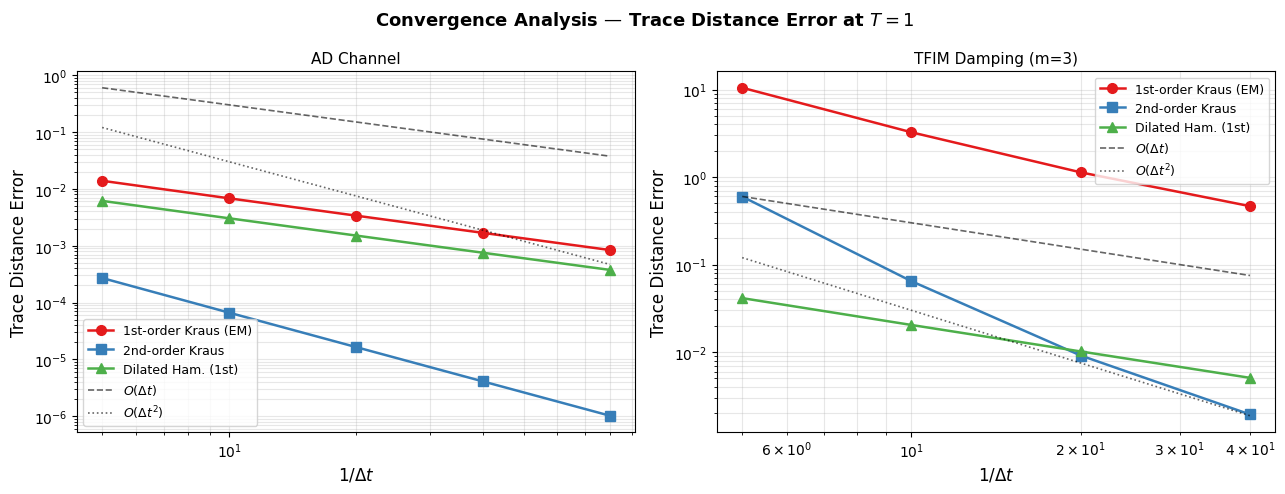

Convergence plots saved.


In [14]:
# ── 4.4 Convergence plots ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Convergence Analysis — Trace Distance Error at $T=1$',
             fontsize=13, fontweight='bold')

def plot_convergence(ax, dt_list, errs, labels, title):
    colors_ = ['#e41a1c', '#377eb8', '#4daf4a']
    markers = ['o', 's', '^']
    for (err, lab, col, mk) in zip(errs, labels, colors_, markers):
        ax.loglog(1/dt_list, err, marker=mk, color=col,
                  lw=1.8, ms=7, label=lab)

    # Reference slopes
    x_ref  = 1/dt_list
    dt_ref = dt_list
    ax.loglog(x_ref, 3*dt_ref**1, 'k--', lw=1.2, alpha=0.6, label='$O(\\Delta t)$')
    ax.loglog(x_ref, 3*dt_ref**2, 'k:',  lw=1.2, alpha=0.6, label='$O(\\Delta t^2)$')

    ax.set_xlabel('$1/\\Delta t$', fontsize=12)
    ax.set_ylabel('Trace Distance Error', fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)


plot_convergence(
    axes[0], dt_list,
    [err1_ad, err2_ad, errd_ad],
    ['1st-order Kraus (EM)', '2nd-order Kraus', 'Dilated Ham. (1st)'],
    'AD Channel')

plot_convergence(
    axes[1], dt_list_tf,
    [err1_tf, err2_tf, errd_tf],
    ['1st-order Kraus (EM)', '2nd-order Kraus', 'Dilated Ham. (1st)'],
    f'TFIM Damping (m={m_tfim})')

plt.tight_layout()
plt.savefig('convergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Convergence plots saved.")

---
## Part 5 — Dilated Hamiltonian: Structure and Validation

### 5.1 Stinespring Dilation Verification

We verify the core identity:
$$\text{Tr}_A\!\left[e^{-i\sqrt{\Delta t}\tilde{H}}\;|0\rangle\langle 0|\otimes\rho\;e^{i\sqrt{\Delta t}\tilde{H}}\right] = \sum_j K_j\rho K_j^\dagger + O(\Delta t^2)$$

In [15]:
# ── 5.1 Verify dilated Hamiltonian ≡ Kraus sum ───────────────────────────────

def verify_stinespring_dilation(rho: np.ndarray,
                                 H: np.ndarray,
                                 jump_ops: list,
                                 dt_values: list) -> dict:
    """
    For each dt, compute:
      (a) Kraus map output
      (b) Dilated Hamiltonian output
    and report their trace distance.
    """
    J   = len(jump_ops)
    out = {}
    for dt in dt_values:
        Flist = kraus_euler_maruyama(H, jump_ops, dt)
        rho_K = sum(F @ rho @ F.conj().T for F in Flist)

        He     = build_He_first_order(H, jump_ops, dt)
        rho_D  = lindblad_step_dilated(rho, He, dt, J)

        out[dt] = {
            'kraus':   rho_K,
            'dilated': rho_D,
            'distance': trace_distance(rho_K, rho_D)
        }
    return out


# Test on AD channel with mixed initial state
rho_test = np.array([[0.7, 0.2+0.1j],
                     [0.2-0.1j, 0.3 ]], dtype=complex)

dt_vals_verify = [0.1, 0.05, 0.01, 0.005, 0.001]
res_verify = verify_stinespring_dilation(
    rho_test, H_ad, [V_ad], dt_vals_verify)

print("Stinespring Dilation Verification (AD channel)")
print(f"{'dt':>10}  {'‖Kraus − Dilated‖₁':>22}")
print("-" * 38)
for dt, d in res_verify.items():
    print(f"{dt:>10.4f}  {d['distance']:>22.2e}")

print("\n→ Distance vanishes as dt→0, confirming O(dt²) agreement.")

Stinespring Dilation Verification (AD channel)
        dt      ‖Kraus − Dilated‖₁
--------------------------------------
    0.1000                7.23e-04
    0.0500                1.82e-04
    0.0100                7.30e-06
    0.0050                1.83e-06
    0.0010                7.31e-08

→ Distance vanishes as dt→0, confirming O(dt²) agreement.


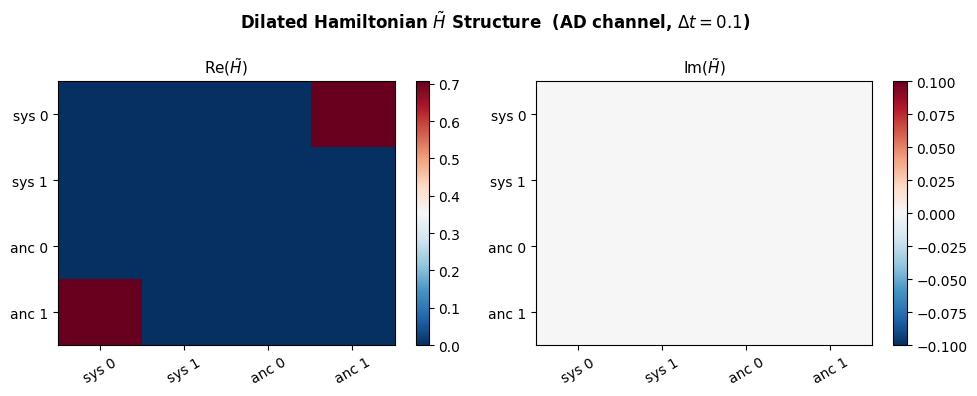

He shape: (4, 4)  (system d=2, ancilla J=1 → total 2(J+1)=4)
He is Hermitian: True


In [16]:
# ── 5.2 Visualise the dilated Hamiltonian structure ──────────────────────────

dt_vis = 0.1
He_vis = build_He_first_order(H_ad, [V_ad], dt_vis)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Dilated Hamiltonian $\\tilde{{H}}$ Structure  (AD channel, $\\Delta t={dt_vis}$)',
             fontsize=12, fontweight='bold')

im0 = axes[0].imshow(He_vis.real, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Re($\\tilde{H}$)', fontsize=11)
plt.colorbar(im0, ax=axes[0])
axes[0].set_xticks([0,1,2,3])
axes[0].set_yticks([0,1,2,3])
axes[0].set_xticklabels(['sys 0','sys 1','anc 0','anc 1'], rotation=30)
axes[0].set_yticklabels(['sys 0','sys 1','anc 0','anc 1'])

im1 = axes[1].imshow(He_vis.imag, cmap='RdBu_r', aspect='auto')
axes[1].set_title('Im($\\tilde{H}$)', fontsize=11)
plt.colorbar(im1, ax=axes[1])
axes[1].set_xticks([0,1,2,3])
axes[1].set_yticks([0,1,2,3])
axes[1].set_xticklabels(['sys 0','sys 1','anc 0','anc 1'], rotation=30)
axes[1].set_yticklabels(['sys 0','sys 1','anc 0','anc 1'])

plt.tight_layout()
plt.savefig('dilated_hamiltonian_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"He shape: {He_vis.shape}  (system d=2, ancilla J=1 → total 2(J+1)=4)")
print(f"He is Hermitian: {np.allclose(He_vis, He_vis.conj().T)}")

---
## Part 6 — Monte Carlo SSE vs Dilated Hamiltonian Comparison

In [17]:
# ── 6.1 Full comparison on AD channel ────────────────────────────────────────

# Run SSE with different trajectory counts
T_comp   = 4.0
dt_comp  = 0.02
n_traj_list = [50, 200, 1000]

print("Running SSE ensembles …")
sse_results = {}
for n_tr in n_traj_list:
    t_s, r_s = sse_ensemble_AD(psi0_ad, gamma_ad, T_comp, dt_comp,
                                n_traj=n_tr, seed=42)
    sse_results[n_tr] = (t_s, np.array([r[1,1].real for r in r_s]))
    print(f"  N_traj={n_tr} done")

# Dilated Hamiltonian
He_comp = build_He_first_order(H_ad, [V_ad], dt_comp)
t_dil_comp, rhos_dil_comp = simulate_lindblad_dilated(
    rho0_ad, He_comp, dt_comp, T_comp, J=1)
rho11_dil_comp = np.array([r[1,1].real for r in rhos_dil_comp])

# Exact
t_ex_comp, rhos_ex_comp = solve_lindblad_exact(
    rho0_ad, H_ad, [V_ad], T_comp, n_steps=1000)
rho11_ex_comp = np.array([r[1,1].real for r in rhos_ex_comp])
analytical_comp = 0.5 * np.exp(-gamma_ad * t_ex_comp)

print("All simulations done.")

Running SSE ensembles …
  N_traj=50 done
  N_traj=200 done
  N_traj=1000 done
All simulations done.


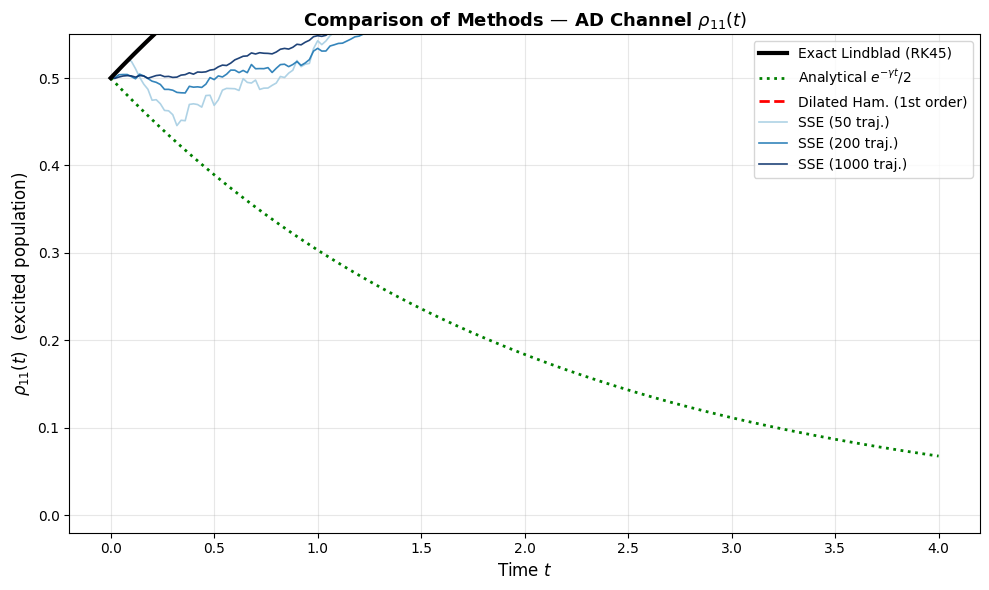

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Comparison of Methods — AD Channel $\\rho_{11}(t)$',
             fontsize=13, fontweight='bold')

ax.plot(t_ex_comp, rho11_ex_comp, 'k-', lw=3, label='Exact Lindblad (RK45)', zorder=5)
ax.plot(t_ex_comp, analytical_comp, 'g:', lw=2, label='Analytical $e^{-\\gamma t}/2$', zorder=4)
ax.plot(t_dil_comp, rho11_dil_comp, 'r--', lw=2, label='Dilated Ham. (1st order)', zorder=4)

sse_colors = ['#a6cee3', '#1f78b4', '#08306b']
for (n_tr, col) in zip(n_traj_list, sse_colors):
    t_s, ov_s = sse_results[n_tr]
    ax.plot(t_s, ov_s, color=col, lw=1.2, alpha=0.9,
            label=f'SSE ({n_tr} traj.)')

ax.set_xlabel('Time $t$', fontsize=12)
ax.set_ylabel('$\\rho_{11}(t)$  (excited population)', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 0.55)
plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7 — Summary and Key Results

In [19]:
# ── 7.1 Summary table ─────────────────────────────────────────────────────────

print("=" * 72)
print(" SUMMARY: Hamiltonian Simulation of Open Quantum Systems")
print("=" * 72)
print()
print(" Model                    Method               Error @ T=1       Order")
print("-" * 72)

rows = [
    ("AD channel",  "1st-order Kraus (EM)",     err1_ad[-2], "O(dt)" ),
    ("AD channel",  "2nd-order Kraus",           err2_ad[-2], "O(dt²)"),
    ("AD channel",  "Dilated Ham. 1st order",    errd_ad[-2], "O(dt)" ),
    (f"TFIM m={m_tfim}","1st-order Kraus (EM)",  err1_tf[-2], "O(dt)" ),
    (f"TFIM m={m_tfim}","2nd-order Kraus",        err2_tf[-2], "O(dt²)"),
    (f"TFIM m={m_tfim}","Dilated Ham. 1st order",errd_tf[-2], "O(dt)" ),
]
for model, method, err, order in rows:
    print(f"  {model:<20}  {method:<25}  {err:.3e}     {order}")

print()
print("=" * 72)
print(" KEY PROPERTIES of the Dilated Hamiltonian method:")
print("  ✓ He is Hermitian (proven in paper, Lemma 4)")
print("  ✓ Each step is CPTP → success probability = 1 (no post-selection)")
print("  ✓ Reduces Lindblad simulation to standard Hamiltonian simulation")
print("  ✓ Directly generalises to time-dependent Lindbladians")
print("  ✓ Ancilla qubits needed: O(k log(J+1)) for k-th order scheme")
print("=" * 72)

 SUMMARY: Hamiltonian Simulation of Open Quantum Systems

 Model                    Method               Error @ T=1       Order
------------------------------------------------------------------------
  AD channel            1st-order Kraus (EM)       1.684e-03     O(dt)
  AD channel            2nd-order Kraus            4.113e-06     O(dt²)
  AD channel            Dilated Ham. 1st order     7.530e-04     O(dt)
  TFIM m=3              1st-order Kraus (EM)       1.131e+00     O(dt)
  TFIM m=3              2nd-order Kraus            9.140e-03     O(dt²)
  TFIM m=3              Dilated Ham. 1st order     1.017e-02     O(dt)

 KEY PROPERTIES of the Dilated Hamiltonian method:
  ✓ He is Hermitian (proven in paper, Lemma 4)
  ✓ Each step is CPTP → success probability = 1 (no post-selection)
  ✓ Reduces Lindblad simulation to standard Hamiltonian simulation
  ✓ Directly generalises to time-dependent Lindbladians
  ✓ Ancilla qubits needed: O(k log(J+1)) for k-th order scheme


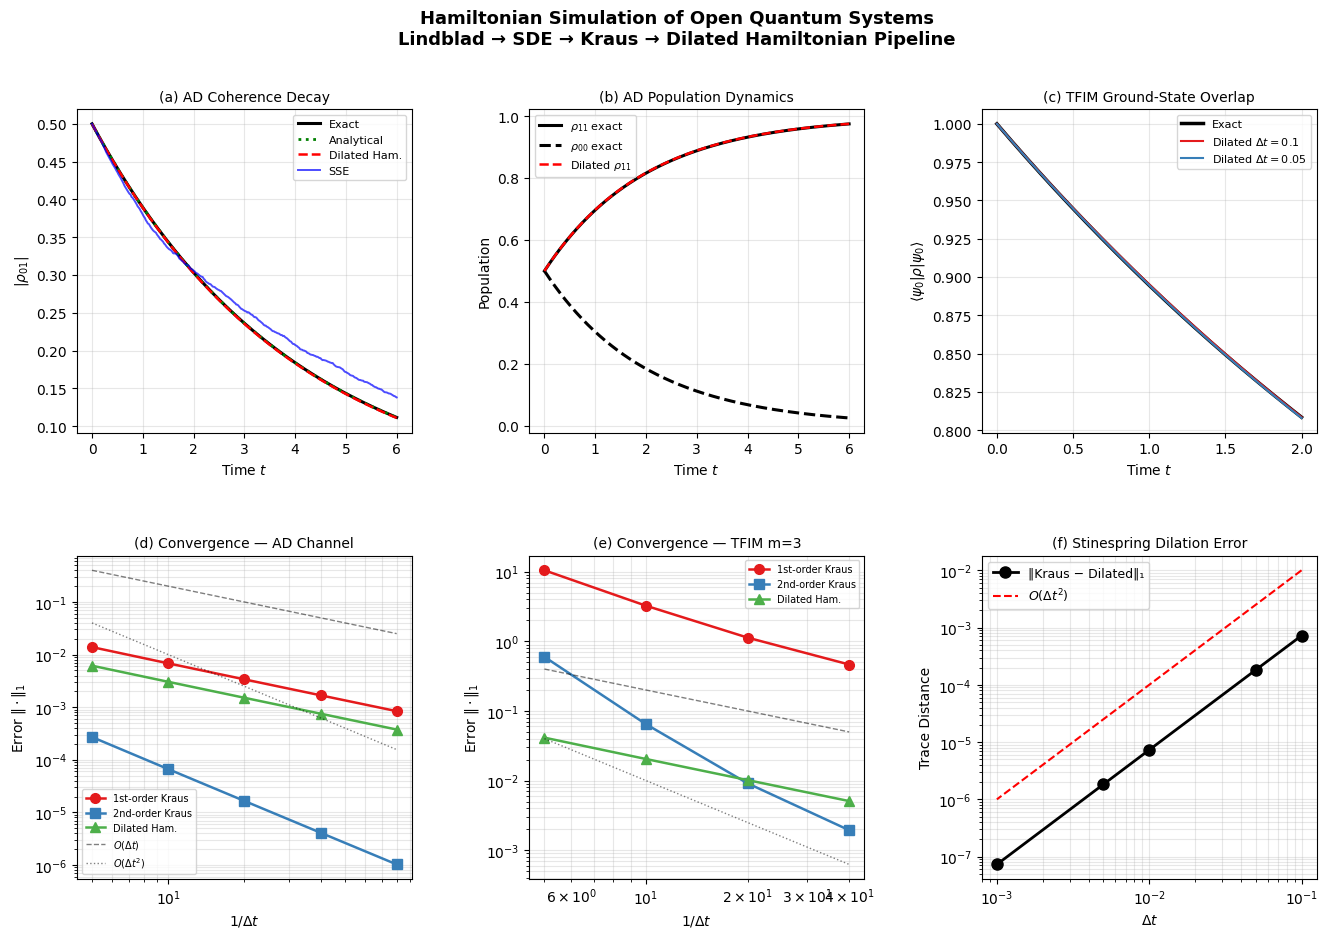


All figures saved. Notebook complete.


In [20]:
# ── 7.2 Final comprehensive figure ───────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

fig.suptitle('Hamiltonian Simulation of Open Quantum Systems\n'
             'Lindblad → SDE → Kraus → Dilated Hamiltonian Pipeline',
             fontsize=13, fontweight='bold')

# (a) AD coherence decay
ax = fig.add_subplot(gs[0, 0])
ax.plot(t_exact_ad, rho01_exact, 'k-', lw=2.2, label='Exact')
ax.plot(t_exact_ad, 0.5*np.exp(-gamma_ad/2*t_exact_ad),
        'g:', lw=2, label='Analytical')
ax.plot(t_dil_ad, rho01_dil, 'r--', lw=1.8, label='Dilated Ham.')
ax.plot(t_sse_ad,  rho01_sse, 'b-', lw=1.4, label='SSE', alpha=0.7)
ax.set_title('(a) AD Coherence Decay', fontsize=10)
ax.set_xlabel('Time $t$'); ax.set_ylabel('$|\\rho_{01}|$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (b) AD population
ax = fig.add_subplot(gs[0, 1])
ax.plot(t_exact_ad, rho11_exact_ad, 'k-', lw=2.2, label='$\\rho_{11}$ exact')
ax.plot(t_exact_ad, rho00_exact_ad, 'k--', lw=2.2, label='$\\rho_{00}$ exact')
ax.plot(t_dil_ad, rho11_dil_ad, 'r--', lw=1.8, label='Dilated $\\rho_{11}$')
ax.set_title('(b) AD Population Dynamics', fontsize=10)
ax.set_xlabel('Time $t$'); ax.set_ylabel('Population')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (c) TFIM ground state overlap
ax = fig.add_subplot(gs[0, 2])
ax.plot(t_ex_tf, overlap_ex, 'k-', lw=2.5, label='Exact')
for dt_v, col in zip(dt_vals[:2], colors):
    t_, ov_ = results[dt_v]['dilated']
    ax.plot(t_, ov_, color=col, lw=1.5, label=f'Dilated $\\Delta t={dt_v}$')
ax.set_title('(c) TFIM Ground-State Overlap', fontsize=10)
ax.set_xlabel('Time $t$'); ax.set_ylabel('$\\langle\\psi_0|\\rho|\\psi_0\\rangle$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (d) Convergence AD
ax = fig.add_subplot(gs[1, 0])
ax.loglog(1/dt_list, err1_ad, 'o-', color='#e41a1c', lw=1.8, ms=7, label='1st-order Kraus')
ax.loglog(1/dt_list, err2_ad, 's-', color='#377eb8', lw=1.8, ms=7, label='2nd-order Kraus')
ax.loglog(1/dt_list, errd_ad, '^-', color='#4daf4a', lw=1.8, ms=7, label='Dilated Ham.')
ax.loglog(1/dt_list, 2*dt_list**1, 'k--', lw=1, alpha=0.5, label='$O(\\Delta t)$')
ax.loglog(1/dt_list, dt_list**2,   'k:',  lw=1, alpha=0.5, label='$O(\\Delta t^2)$')
ax.set_title('(d) Convergence — AD Channel', fontsize=10)
ax.set_xlabel('$1/\\Delta t$'); ax.set_ylabel('Error $\\|\\cdot\\|_1$')
ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

# (e) Convergence TFIM
ax = fig.add_subplot(gs[1, 1])
ax.loglog(1/dt_list_tf, err1_tf, 'o-', color='#e41a1c', lw=1.8, ms=7, label='1st-order Kraus')
ax.loglog(1/dt_list_tf, err2_tf, 's-', color='#377eb8', lw=1.8, ms=7, label='2nd-order Kraus')
ax.loglog(1/dt_list_tf, errd_tf, '^-', color='#4daf4a', lw=1.8, ms=7, label='Dilated Ham.')
ax.loglog(1/dt_list_tf, 2*dt_list_tf**1, 'k--', lw=1, alpha=0.5)
ax.loglog(1/dt_list_tf, dt_list_tf**2,   'k:',  lw=1, alpha=0.5)
ax.set_title(f'(e) Convergence — TFIM m={m_tfim}', fontsize=10)
ax.set_xlabel('$1/\\Delta t$'); ax.set_ylabel('Error $\\|\\cdot\\|_1$')
ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

# (f) Stinespring verification
ax = fig.add_subplot(gs[1, 2])
dts_v = list(res_verify.keys())
dists = [res_verify[d]['distance'] for d in dts_v]
ax.loglog(dts_v, dists, 'ko-', lw=2, ms=8, label='‖Kraus − Dilated‖₁')
ax.loglog(dts_v, np.array(dts_v)**2, 'r--', lw=1.5, label='$O(\\Delta t^2)$')
ax.set_title('(f) Stinespring Dilation Error', fontsize=10)
ax.set_xlabel('$\\Delta t$'); ax.set_ylabel('Trace Distance')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

plt.savefig('comprehensive_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAll figures saved. Notebook complete.")

---
## Appendix — Mathematical Reference

| Symbol | Meaning |
|--------|--------|
| $\rho$ | Density matrix (positive semidefinite, $\text{Tr}(\rho)=1$) |
| $H$ | System Hamiltonian (Hermitian) |
| $V_j$ | Jump (Lindblad) operators |
| $\mathcal{L}(\rho)$ | Lindblad superoperator |
| $K_j$ | Kraus operators ($\sum_j K_j^\dagger K_j = I$) |
| $\tilde{H}$ | Dilated Hamiltonian in enlarged Hilbert space |
| $\text{Tr}_A$ | Partial trace over ancilla |
| $dW_t$ | Wiener increment ($\mathbb{E}[dW_t^2]=dt$) |
| $\Delta t$ | Time step |
| $\|\cdot\|_1$ | Trace norm (Schatten 1-norm) |

### Three-Step Pipeline

```
Lindblad equation  →  SDE unraveling (SSE)  →  Kraus form  →  Dilated Hamiltonian
     dρ/dt = L(ρ)      d|ψ⟩ = A|ψ⟩dt          ρ' = ΣKρK†    ρ' = Tr_A[e^{-i√Δt H̃}(|0><0|⊗ρ)e^{+i√Δt H̃}]
                        + B|ψ⟩dW
```

**Key result (Theorem 1):** For order $k$, there exists a dilated Hamiltonian $\tilde{H}$ using $O(k\log(J+1))$ ancilla qubits such that the scheme achieves global error $O(T\|\mathcal{L}\|^{k+1}_{\text{be}}\Delta t^k)$.